In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

In [70]:
# inDir=Path('..')/'..'/'input'
# outDir=Path('..')/'output'

In [71]:
RANDOM_STATE=24
np.random.seed(RANDOM_STATE)

In [72]:
TEST_SIZE=0.2
params={'legend.fontsize':'medium',
        'figure.figsize':(15,6),
        'axes.labelsize':'large',
        'axes.titlesize':'large',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'
        }

In [73]:
CMAP=plt.cm.coolwarm
plt.rcParams.update(params)

In [74]:
df=pd.read_csv(r"C:\Users\dai\Desktop\DeepLearning\day1\breast_cancer_mod.csv")


In [75]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,1,1,0
1,0,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,1,0,1,1,0
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,1,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
565,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
566,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
567,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [76]:
for col in df.columns:
    print(f"col:{col}--{df[col].unique()}")

col:mean radius--[0 1]
col:mean texture--[0 1]
col:mean perimeter--[0 1]
col:mean area--[0 1]
col:mean smoothness--[0 1]
col:mean compactness--[0 1]
col:mean concavity--[0 1]
col:mean concave points--[0 1]
col:mean symmetry--[0 1]
col:mean fractal dimension--[1 0]
col:radius error--[0 1]
col:texture error--[1 0]
col:perimeter error--[0 1]
col:area error--[0 1]
col:smoothness error--[1 0]
col:compactness error--[1 0]
col:concavity error--[1 0]
col:concave points error--[1 0]
col:symmetry error--[1 0]
col:fractal dimension error--[1 0]
col:worst radius--[0 1]
col:worst texture--[0 1]
col:worst perimeter--[0 1]
col:worst area--[0 1]
col:worst smoothness--[1 0]
col:worst compactness--[1 0]
col:worst concavity--[0 1]
col:worst concave points--[0 1]
col:worst symmetry--[1 0]
col:worst fractal dimension--[1 0]
col:target--[0 1]


<BarContainer object of 2 artists>

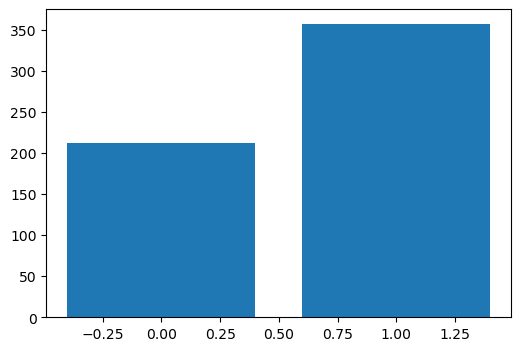

In [77]:
labels=["Malignant","Benign"]
fig,ax=plt.subplots(figsize=(6,4))
ax.bar(df["target"].value_counts().index,
       df["target"].value_counts().values)

In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,0.820738,0.383909,0.0,1.0,1.0,1.0,1.0
mean texture,569.0,0.880492,0.324671,0.0,1.0,1.0,1.0,1.0
mean perimeter,569.0,0.827768,0.377914,0.0,1.0,1.0,1.0,1.0
mean area,569.0,0.954306,0.209005,0.0,1.0,1.0,1.0,1.0
mean smoothness,569.0,0.811951,0.391095,0.0,1.0,1.0,1.0,1.0
mean compactness,569.0,0.910369,0.285904,0.0,1.0,1.0,1.0,1.0
mean concavity,569.0,0.917399,0.275520,0.0,1.0,1.0,1.0,1.0
mean concave points,569.0,0.899824,0.300498,0.0,1.0,1.0,1.0,1.0
mean symmetry,569.0,0.831283,0.374831,0.0,1.0,1.0,1.0,1.0
mean fractal dimension,569.0,0.927944,0.258809,0.0,1.0,1.0,1.0,1.0


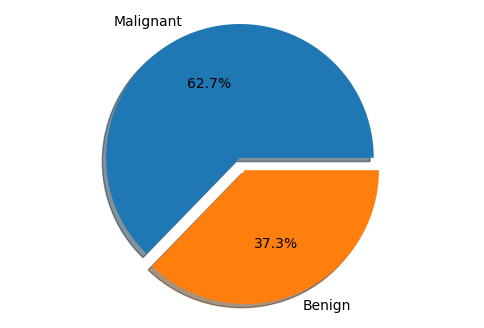

In [79]:
labels=["Malignant","Benign"]
fig,ax=plt.subplots(figsize=(6,4))
explode=(0,0.1)
ax.pie(df["target"].value_counts(),
      explode=explode,
       autopct="%1.1f%%",
       labels=labels,
      shadow=True,
      startangle=0)

ax.axis("equal");

### 

In [80]:
ax.pie?

Signature:
ax.pie(
    x,
    explode=None,
    labels=None,
    colors=None,
    autopct=None,
    pctdistance=0.6,
    shadow=False,
    labeldistance=1.1,
    startangle=0,
    radius=1,
    counterclock=True,
    wedgeprops=None,
    textprops=None,
    center=(0, 0),
    frame=False,
    rotatelabels=False,
    *,
    normalize=True,
    hatch=None,
    data=None,
)
Docstring:
Plot a pie chart.

Make a pie chart of array *x*.  The fractional area of each wedge is
given by ``x/sum(x)``.

The wedges are plotted counterclockwise, by default starting from the
x-axis.

Parameters
----------
x : 1D array-like
    The wedge sizes.

explode : array-like, default: None
    If not *None*, is a ``len(x)`` array which specifies the fraction
    of the radius with which to offset each wedge.

labels : list, default: None
    A sequence of strings providing the labels for each wedge

colors : color or array-like of color, default: None
    A sequence of colors through which the pie chart will c

In [81]:
features=df.drop("target",axis=1)
labels=df["target"]
type(features),type(labels)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [82]:
x_train,x_test,y_train,y_test=train_test_split(features,labels,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=labels)

In [83]:
x_train["total"]=x_train.astype(np.int16).sum(axis=1)
x_train["target"]=y_train
x_train.sort_values("total",inplace=True)
x_train.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,total,target
0,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,1,1,12,0
2,0,1,0,0,0,0,0,0,0,1,...,0,1,0,1,1,0,1,1,13,0
1,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,13,0
7,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,15,0
6,0,0,0,0,1,0,0,0,1,1,...,0,0,0,0,0,0,1,1,15,0


In [86]:
accuracy={}
for b in range(x_train.shape[1]):  
    x_train["pred"]=x_train["total"]>=b
    accuracy[b]= accuracy_score(x_train["target"],x_train['pred'])
best_b= max(accuracy,key=accuracy.get)
accuracy[best_b]
    


0.8505494505494505